In [40]:
import os
from pathlib import Path
from collections import Counter, defaultdict
from itertools import combinations
import warnings as warn

import pickle

import networkx as nx
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from typing import Any
#os.chdir("AWS_theDiceGame")

# ==============================================================================
# SECCIÓN 1: CONFIGURACIÓN DEL ENTORNO Y BIBLIOTECAS
# ==============================================================================

In [41]:
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.linestyle': '--',
    'grid.alpha': 0.5
})

warn.filterwarnings("ignore", category=UserWarning)

In [42]:
BASE_DIR = Path(".")
DATA_DIR = BASE_DIR / "data"
GRAPHS_DIR = DATA_DIR / "graphs"
SERVICES_CSV = DATA_DIR / "services.csv"

# ==============================================================================
# SECCIÓN 2: CARGA DEL DATASET Y CATÁLOGO DE SERVICIOS
# ==============================================================================

In [43]:
def load_services_catalog(csv_path: Path) -> pl.DataFrame:
    if not csv_path.exists():
        raise FileNotFoundError(f"No se encontró el archivo: {csv_path}")

    df_services = pl.read_csv(csv_path)

    df_services = df_services.with_columns([
        pl.col("name").str.strip_chars().alias("service_name"),
        pl.col("capability").str.strip_chars().alias("capability"),
        pl.col("is_aws").cast(pl.Boolean).alias("is_aws")
    ])

    return df_services

def load_usable_graphml_dataset(graphs_dir: Path) -> dict[str, nx.MultiDiGraph]:
    if not graphs_dir.exists():
        raise FileNotFoundError(f"Directorio de grafos no encontrado: {graphs_dir}")

    graphs_dict = {}
    total_files = 0
    discarded_files = 0

    for graphml_file in graphs_dir.glob("*.graphml"):
        total_files += 1
        arch_id = graphml_file.stem
        try:
            G = nx.read_graphml(graphml_file)

            usable_attr = str(G.graph.get("graph_usable", "False")).strip().lower()

            if usable_attr == "true":
                graphs_dict[arch_id] = G
            else:
                discarded_files += 1

        except Exception as e:
            print(f"⚠️ Error cargando {graphml_file.name}: {e}")
            discarded_files += 1

    print(f" Carga de Grafos Finalizada:")
    print(f"   - Archivos procesados: {total_files}")
    print(f"   - Arquitecturas usables cargadas: {len(graphs_dict)}[cite: 1]")
    print(f"   - Arquitecturas descartadas/no usables: {discarded_files}[cite: 1]")

    return graphs_dict


In [44]:
df_services = load_services_catalog(SERVICES_CSV)
raw_graphs = load_usable_graphml_dataset(GRAPHS_DIR)

print("\nVista previa del catálogo de servicios (Polars DataFrame):")
print(df_services.select(["service_name", "capability", "is_aws"]).head(5))

 Carga de Grafos Finalizada:
   - Archivos procesados: 396
   - Arquitecturas usables cargadas: 340[cite: 1]
   - Arquitecturas descartadas/no usables: 56[cite: 1]

Vista previa del catálogo de servicios (Polars DataFrame):
shape: (5, 3)
┌──────────────────────┬────────────┬────────┐
│ service_name         ┆ capability ┆ is_aws │
│ ---                  ┆ ---        ┆ ---    │
│ str                  ┆ str        ┆ bool   │
╞══════════════════════╪════════════╪════════╡
│ Transcribe           ┆ compute    ┆ true   │
│ LookoutForVision     ┆ compute    ┆ true   │
│ PrivateLink          ┆ networking ┆ true   │
│ SystemsManager       ┆ control    ┆ true   │
│ UserCompanyDeveloper ┆ User       ┆ false  │
└──────────────────────┴────────────┴────────┘


# ==============================================================================
# SECCIÓN 3: EXTRACCIÓN MODULAR Y NORMALIZACIÓN TOPOLÓGICA
# ==============================================================================


In [45]:
def extract_architecture_metadata(arch_id: str, G: nx.MultiDiGraph) -> dict[str, Any]:
    graph_data = G.graph
    return {
        "arch_id": arch_id,
        "name": str(graph_data.get("name", "Unknown")),
        "link": str(graph_data.get("link", "")),
        "categories": str(graph_data.get("categories", "other")),
        "notes": str(graph_data.get("notes", "")),
        "num_nodes": G.number_of_nodes(),
        "num_edges": G.number_of_edges()
    }

def extract_nodes_metadata(arch_id: str, G: nx.MultiDiGraph) -> list[dict[str, Any]]:
    nodes_records = []
    for node_id in G.nodes():
        data = G.nodes[node_id]
        if not isinstance(data, dict):
            data = {}
        service_name = str(data.get("service", node_id)).strip()
        nodes_records.append({
            "arch_id": arch_id,
            "node_id": str(node_id),
            "service": service_name,
            "custom_name": str(data.get("name", "")),  # Útil en nodos ThirdParty[cite: 1]
            "notes": str(data.get("notes", ""))
        })
    return nodes_records

def extract_edges_metadata(arch_id: str, G: nx.MultiDiGraph) -> list[dict[str, Any]]:
    edges_records = []
    for u in G.nodes():
        nbrs = G[u]
        for v, keydict in nbrs.items():
            for key, data in keydict.items():
                if not isinstance(data, dict):
                    data = {}
                edges_records.append({
                    "arch_id": arch_id,
                    "source": str(u),
                    "target": str(v),
                    "edge_key": str(key),
                    "flow_id": str(data.get("flow_id", "0")),
                    "seq": str(data.get("seq", "0")),
                    "type": str(data.get("type", "unknown")),
                    "notes": str(data.get("notes", ""))
                })
    return edges_records

def process_all_graphs(graphs_dict: dict[str, nx.MultiDiGraph]) -> tuple[list, list, list]:
    all_archs = []
    all_nodes = []
    all_edges = []

    for arch_id, G in graphs_dict.items():
        all_archs.append(extract_architecture_metadata(arch_id, G))
        all_nodes.extend(extract_nodes_metadata(arch_id, G))
        all_edges.extend(extract_edges_metadata(arch_id, G))

    return all_archs, all_nodes, all_edges

In [46]:
records_archs, records_nodes, records_edges = process_all_graphs(raw_graphs)
print(f" Extracción completada:")
print(f"   - Arquitecturas extraídas: {len(records_archs)}")
print(f"   - Registros de nodos extraídos: {len(records_nodes)}")
print(f"   - Registros de aristas extraídas: {len(records_edges)}")

 Extracción completada:
   - Arquitecturas extraídas: 340
   - Registros de nodos extraídos: 3102
   - Registros de aristas extraídas: 15884


# ==============================================================================
# SECCIÓN 4: CONSTRUCCIÓN DEL DATASET REUTILIZABLE (POLARS + GRAFOS)
# ==============================================================================

In [47]:
class CloudscapeDataset:
    def __init__(
        self,
        df_architectures: pl.DataFrame,
        df_nodes: pl.DataFrame,
        df_edges: pl.DataFrame,
        graphs: dict[str, nx.MultiDiGraph]
    ):
        self.architectures = df_architectures
        self.nodes = df_nodes
        self.edges = df_edges
        self.graphs = graphs

def build_cloudscape_dataset(
    records_archs: list,
    records_nodes: list,
    records_edges: list,
    df_services_catalog: pl.DataFrame,
    graphs_dict: dict[str, nx.MultiDiGraph]
) -> CloudscapeDataset:

    df_archs = pl.DataFrame(records_archs).with_columns([
        pl.col("categories").str.split(",").alias("category_list")
    ])

    df_nodes = pl.DataFrame(records_nodes)
    df_nodes = df_nodes.join(
        df_services_catalog,
        left_on="service",
        right_on="service_name",
        how="left"
    ).with_columns([
        pl.col("capability").fill_null("Other/External"),
        pl.col("is_aws").fill_null(False)
    ])

    df_edges = pl.DataFrame(records_edges)

    return CloudscapeDataset(df_archs, df_nodes, df_edges, graphs_dict)

In [48]:
dataset = build_cloudscape_dataset(
    records_archs,
    records_nodes,
    records_edges,
    df_services,
    raw_graphs
)

print(" Estructura relacional creada exitosamente.")
print("\n--- Esquema del DataFrame Enriquecido de Nodos (Polars) ---")
print(dataset.nodes.select(["arch_id", "node_id", "service", "capability", "is_aws"]).head(5))

print("\n--- Esquema del DataFrame de Aristas (Polars) ---")
print(dataset.edges.select(["arch_id", "source", "target", "flow_id", "type"]).head(5))

 Estructura relacional creada exitosamente.

--- Esquema del DataFrame Enriquecido de Nodos (Polars) ---
shape: (5, 5)
┌─────────────┬─────────┬────────────┬────────────┬────────┐
│ arch_id     ┆ node_id ┆ service    ┆ capability ┆ is_aws │
│ ---         ┆ ---     ┆ ---        ┆ ---        ┆ ---    │
│ str         ┆ str     ┆ str        ┆ str        ┆ bool   │
╞═════════════╪═════════╪════════════╪════════════╪════════╡
│ WS2Qgx0qgCM ┆ 0       ┆ EC2        ┆ compute    ┆ true   │
│ WS2Qgx0qgCM ┆ 1       ┆ EC2        ┆ compute    ┆ true   │
│ WS2Qgx0qgCM ┆ 2       ┆ CloudTrail ┆ control    ┆ true   │
│ WS2Qgx0qgCM ┆ 3       ┆ OpenSearch ┆ compute    ┆ true   │
│ WS2Qgx0qgCM ┆ 4       ┆ STS        ┆ control    ┆ true   │
└─────────────┴─────────┴────────────┴────────────┴────────┘

--- Esquema del DataFrame de Aristas (Polars) ---
shape: (5, 5)
┌─────────────┬────────┬────────┬─────────┬─────────┐
│ arch_id     ┆ source ┆ target ┆ flow_id ┆ type    │
│ ---         ┆ ---    ┆ ---    ┆ ---

# ==============================================================================
# SECCIÓN 5: EXPLORACIÓN UNIVARIADA Y DISTRIBUCIONES GENERALES
# ==============================================================================

 RESUMEN MACRO DEL DATASET:
   • Total de arquitecturas analizables: 340
   • Tipos de nodos/servicios únicos totales: 160
   • Servicios netamente AWS únicos identificados: 129

 ESTADÍSTICAS DESCRIPTIVAS DEL TAMAÑO DE ARQUITECTURAS:
shape: (9, 3)
┌────────────┬───────────┬───────────┐
│ statistic  ┆ num_nodes ┆ num_edges │
│ ---        ┆ ---       ┆ ---       │
│ str        ┆ f64       ┆ f64       │
╞════════════╪═══════════╪═══════════╡
│ count      ┆ 340.0     ┆ 340.0     │
│ null_count ┆ 0.0       ┆ 0.0       │
│ mean       ┆ 9.123529  ┆ 12.305882 │
│ std        ┆ 2.231982  ┆ 4.915267  │
│ min        ┆ 4.0       ┆ 3.0       │
│ 25%        ┆ 8.0       ┆ 9.0       │
│ 50%        ┆ 9.0       ┆ 12.0      │
│ 75%        ┆ 10.0      ┆ 15.0      │
│ max        ┆ 17.0      ┆ 38.0      │
└────────────┴───────────┴───────────┘

TOP 15 SERVICIOS MÁS UTILIZADOS:
shape: (15, 5)
┌───────────────┬───────────────────┬────────┬─────────────┬────────────┐
│ service       ┆ num_architectures ┆ is_aw

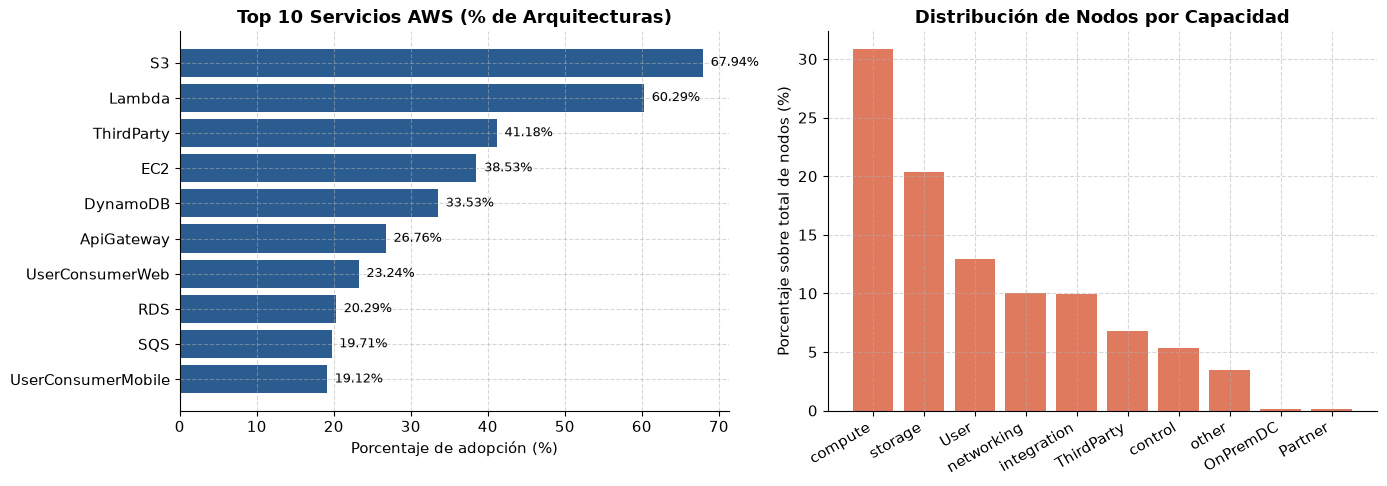

In [49]:
num_archs = dataset.architectures.height
num_unique_services = dataset.nodes.select(pl.col("service").n_unique()).item()
num_aws_services = dataset.nodes.filter(pl.col("is_aws") == True).select(pl.col("service").n_unique()).item()

print(" RESUMEN MACRO DEL DATASET:")
print(f"   • Total de arquitecturas analizables: {num_archs}")
print(f"   • Tipos de nodos/servicios únicos totales: {num_unique_services}")
print(f"   • Servicios netamente AWS únicos identificados: {num_aws_services}")

print("\n ESTADÍSTICAS DESCRIPTIVAS DEL TAMAÑO DE ARQUITECTURAS:")
stats_archs = dataset.architectures.select([
    pl.col("num_nodes"),
    pl.col("num_edges")
]).describe()
print(stats_archs)

df_service_pop = (
    dataset.nodes
    .group_by("service")
    .agg([
        pl.col("arch_id").n_unique().alias("num_architectures"),
        pl.col("is_aws").first().alias("is_aws"),
        pl.col("capability").first().alias("capability")
    ])
    .with_columns(
        ((pl.col("num_architectures") / num_archs) * 100).round(2).alias("percentage")
    )
    .sort("num_architectures", descending=True)
)

print("\nTOP 15 SERVICIOS MÁS UTILIZADOS:")
print(df_service_pop.head(15))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_10 = df_service_pop.head(10)
services_list = top_10["service"].to_list()[::-1]
pct_list = top_10["percentage"].to_list()[::-1]

axes[0].barh(services_list, pct_list, color="#2b5c8f")
axes[0].set_title("Top 10 Servicios AWS (% de Arquitecturas)", fontweight="bold")
axes[0].set_xlabel("Porcentaje de adopción (%)")
for i, v in enumerate(pct_list):
    axes[0].text(v + 1, i, f"{v}%", va='center', fontsize=9)

df_cap = (
    dataset.nodes
    .group_by("capability")
    .agg(pl.len().alias("count"))
    .with_columns(((pl.col("count") / dataset.nodes.height) * 100).round(2).alias("pct"))
    .sort("count", descending=True)
)
cap_list = df_cap["capability"].to_list()
cap_pct_list = df_cap["pct"].to_list()

axes[1].bar(cap_list, cap_pct_list, color="#e07a5f")
axes[1].set_title("Distribución de Nodos por Capacidad", fontweight="bold")
axes[1].set_ylabel("Porcentaje sobre total de nodos (%)")
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30, ha="right")

plt.tight_layout()
plt.show()

# ==============================================================================
# SECCIÓN 6: MINERÍA DE GRAFOS Y TOPOLOGÍA CLOUD
# ==============================================================================

 Distribución de Tipos de Interacción (Aristas)[cite: 1]:
shape: (3, 3)
┌─────────┬───────┬────────────┐
│ type    ┆ count ┆ percentage │
│ ---     ┆ ---   ┆ ---        │
│ str     ┆ u32   ┆ f64        │
╞═════════╪═══════╪════════════╡
│ unknown ┆ 14625 ┆ 92.07      │
│ data    ┆ 978   ┆ 6.16       │
│ meta    ┆ 281   ┆ 1.77       │
└─────────┴───────┴────────────┘

 Top 10 Servicios por Grado Topológico (Interacciones de Salida vs Entrada)[cite: 1]:
shape: (10, 5)
┌─────────────────┬──────────────────┬─────────────────┬─────────────────┬──────────────┐
│ source_service  ┆ out_degree_total ┆ target_service  ┆ in_degree_total ┆ total_degree │
│ ---             ┆ ---              ┆ ---             ┆ ---             ┆ ---          │
│ str             ┆ u32              ┆ str             ┆ u32             ┆ u32          │
╞═════════════════╪══════════════════╪═════════════════╪═════════════════╪══════════════╡
│ Lambda          ┆ 2075             ┆ Lambda          ┆ 1990            ┆ 4065

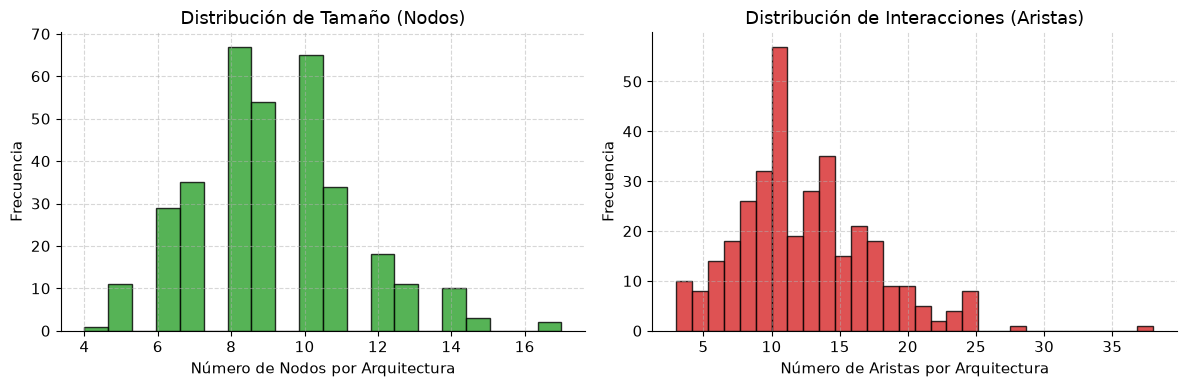

In [50]:
df_edge_types = (
    dataset.edges
    .group_by("type")
    .len(name="count")
    .with_columns(
        ((pl.col("count") / dataset.edges.height) * 100).round(2).alias("percentage")
    )
    .sort("count", descending=True)
)

print(" Distribución de Tipos de Interacción (Aristas)[cite: 1]:")
print(df_edge_types)

df_edges_named = (
    dataset.edges
    .join(dataset.nodes.select(["arch_id", "node_id", "service"]),
          left_on=["arch_id", "source"], right_on=["arch_id", "node_id"], how="inner")
    .rename({"service": "source_service"})
    .join(dataset.nodes.select(["arch_id", "node_id", "service"]),
          left_on=["arch_id", "target"], right_on=["arch_id", "node_id"], how="inner")
    .rename({"service": "target_service"})
)

df_writers = (
    df_edges_named
    .group_by("source_service")
    .len(name="out_degree_total")
    .sort("out_degree_total", descending=True)
)

df_readers = (
    df_edges_named
    .group_by("target_service")
    .len(name="in_degree_total")
    .sort("in_degree_total", descending=True)
)

df_topology_roles = (
    df_writers.join(df_readers, left_on="source_service", right_on="target_service", how="full")
    .fill_null(0)
    .with_columns(
        (pl.col("out_degree_total") + pl.col("in_degree_total")).alias("total_degree")
    )
    .sort("total_degree", descending=True)
)

print("\n Top 10 Servicios por Grado Topológico (Interacciones de Salida vs Entrada)[cite: 1]:")
print(df_topology_roles.head(10))

nodes_list = dataset.architectures["num_nodes"].to_list()
edges_list = dataset.architectures["num_edges"].to_list()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(nodes_list, bins=20, color="#2ca02c", edgecolor="black", alpha=0.8)
ax1.set_xlabel("Número de Nodos por Arquitectura")
ax1.set_ylabel("Frecuencia")
ax1.set_title("Distribución de Tamaño (Nodos)")

ax2.hist(edges_list, bins=30, color="#d62728", edgecolor="black", alpha=0.8)
ax2.set_xlabel("Número de Aristas por Arquitectura")
ax2.set_ylabel("Frecuencia")
ax2.set_title("Distribución de Interacciones (Aristas)")

plt.tight_layout()
plt.show()

# ==============================================================================
# SECCIÓN 7: ANÁLISIS RELACIONAL Y COOCURRENCIAS (POLARS)
# ==============================================================================

In [51]:
print(" CALCULANDO COOCURRENCIAS Y PROBABILIDADES EMPÍRICAS DE TRANSICIÓN...")

arch_services_df = (
    dataset.nodes
    .filter(pl.col("is_aws") == True)  # Nos enfocamos en servicios netamente AWS para los dados
    .group_by("arch_id")
    .agg(pl.col("service").unique().alias("unique_services"))
)

cooc_counter = Counter()
service_arch_count = Counter()

for services_list in arch_services_df["unique_services"].to_list():
    for s in services_list:
        service_arch_count[s] += 1
    for s1, s2 in combinations(sorted(services_list), 2):
        cooc_counter[(s1, s2)] += 1

cooc_records = []
for (s1, s2), count in cooc_counter.items():
    union_count = service_arch_count[s1] + service_arch_count[s2] - count
    jaccard = count / union_count if union_count > 0 else 0.0
    cooc_records.append({
        "service_a": s1,
        "service_b": s2,
        "cooc_frequency": count,
        "jaccard_similarity": round(jaccard, 4)
    })

df_cooccurrences = pl.DataFrame(cooc_records).sort("cooc_frequency", descending=True)
print("\nTop 10 Pares de Servicios con Mayor Coocurrencia No Dirigida:")
print(df_cooccurrences.head(10))

df_transitions = (
    df_edges_named
    .filter((pl.col("source_service") != pl.col("target_service"))) # Excluimos auto-bucles topológicos
    .group_by(["source_service", "target_service"])
    .len(name="interaction_count")
    .join(df_writers, on="source_service", how="left")
    .with_columns(
        (pl.col("interaction_count") / pl.col("out_degree_total")).round(4).alias("prob_transition")
    )
    .sort("interaction_count", descending=True)
)

print("\n➡ Top 10 Flujos Dirigidos Reales (Probabilidad de Transición P(S_j | S_i)):")
print(df_transitions.select(["source_service", "target_service", "interaction_count", "prob_transition"]).head(10))

 CALCULANDO COOCURRENCIAS Y PROBABILIDADES EMPÍRICAS DE TRANSICIÓN...

Top 10 Pares de Servicios con Mayor Coocurrencia No Dirigida:
shape: (10, 4)
┌────────────┬───────────┬────────────────┬────────────────────┐
│ service_a  ┆ service_b ┆ cooc_frequency ┆ jaccard_similarity │
│ ---        ┆ ---       ┆ ---            ┆ ---                │
│ str        ┆ str       ┆ i64            ┆ f64                │
╞════════════╪═══════════╪════════════════╪════════════════════╡
│ Lambda     ┆ S3        ┆ 144            ┆ 0.4932             │
│ DynamoDB   ┆ Lambda    ┆ 92             ┆ 0.4053             │
│ EC2        ┆ S3        ┆ 86             ┆ 0.3116             │
│ DynamoDB   ┆ S3        ┆ 76             ┆ 0.2825             │
│ ApiGateway ┆ Lambda    ┆ 75             ┆ 0.3394             │
│ EC2        ┆ Lambda    ┆ 63             ┆ 0.2308             │
│ ApiGateway ┆ S3        ┆ 56             ┆ 0.2105             │
│ RDS        ┆ S3        ┆ 47             ┆ 0.1858             │
│ S3   

# ==============================================================================
# SECCIÓN 8: PREPARACIÓN PARA EL MODELO PROBABILÍSTICO Y OPTIMIZACIÓN
# ==============================================================================

In [52]:

df_services_master = (
    df_service_pop
    .join(df_topology_roles, left_on="service", right_on="source_service", how="left")
    .drop("target_service")
    .fill_null(0)
    .with_columns([
        (pl.col("num_architectures") / pl.col("num_architectures").sum()).round(6).alias("base_prob_weight"),
        (pl.col("out_degree_total") / (pl.col("total_degree") + 1)).round(4).alias("source_sink_ratio")
    ])
    .sort("num_architectures", descending=True)
)
print(df_services_master.select([
    "service", "capability", "num_architectures", "base_prob_weight", "total_degree", "source_sink_ratio"
]).head(10))

G_cooc_master = nx.Graph()
for row in df_cooccurrences.iter_rows(named=True):
    if row["cooc_frequency"] >= 3:
        G_cooc_master.add_edge(
            row["service_a"],
            row["service_b"],
            weight=row["cooc_frequency"],
            jaccard=row["jaccard_similarity"]
        )

print(f"\n️ Grafo Maestro de Coocurrencia construido: {G_cooc_master.number_of_nodes()} nodos, {G_cooc_master.number_of_edges()} aristas significativas.")

shape: (10, 6)
┌─────────────────┬─────────────┬─────────────────┬────────────────┬──────────────┬────────────────┐
│ service         ┆ capability  ┆ num_architectur ┆ base_prob_weig ┆ total_degree ┆ source_sink_ra │
│ ---             ┆ ---         ┆ es              ┆ ht             ┆ ---          ┆ tio            │
│ str             ┆ str         ┆ ---             ┆ ---            ┆ u32          ┆ ---            │
│                 ┆             ┆ u32             ┆ f64            ┆              ┆ f64            │
╞═════════════════╪═════════════╪═════════════════╪════════════════╪══════════════╪════════════════╡
│ S3              ┆ storage     ┆ 231             ┆ 0.087833       ┆ 3350         ┆ 0.4628         │
│ Lambda          ┆ compute     ┆ 205             ┆ 0.077947       ┆ 4065         ┆ 0.5103         │
│ ThirdParty      ┆ ThirdParty  ┆ 140             ┆ 0.053232       ┆ 1745         ┆ 0.4937         │
│ EC2             ┆ compute     ┆ 131             ┆ 0.04981        ┆ 2483   

# ==============================================================================
# SECCIÓN 9: EXPORTACIÓN Y PRESERVACIÓN DEL ESTADO DEL PROYECTO
# ==============================================================================

In [53]:
OUTPUT_DIR = BASE_DIR / "output_analytics"
OUTPUT_DIR.mkdir(exist_ok=True)

dataset.architectures.write_parquet(OUTPUT_DIR / "cloudscape_architectures.parquet")
dataset.nodes.write_parquet(OUTPUT_DIR / "cloudscape_nodes.parquet")
dataset.edges.write_parquet(OUTPUT_DIR / "cloudscape_edges.parquet")

df_services_master.write_csv(OUTPUT_DIR / "services_master_optimization.csv")
df_cooccurrences.write_csv(OUTPUT_DIR / "services_cooccurrences.csv")
df_transitions.write_csv(OUTPUT_DIR / "services_transitions.csv")

dataset.architectures.with_columns(
    pl.col("category_list").list.join(", ")
).write_csv(OUTPUT_DIR / "cloudscape_architectures.csv")

print(f"    Tablas analíticas exportadas a Parquet/CSV en la carpeta: '{OUTPUT_DIR}'")

bundle_path = OUTPUT_DIR / "cloudscape_pipeline_bundle.pkl"
bundle_data = {
    "dataset": dataset,
    "df_services_master": df_services_master,
    "df_cooccurrences": df_cooccurrences,
    "df_transitions": df_transitions,
    "G_cooc_master": G_cooc_master
}

with open(bundle_path, "wb") as f:
    pickle.dump(bundle_data, f)

print(f"    Bundle binario maestro exportado con éxito en: '{bundle_path.name}'")


    Tablas analíticas exportadas a Parquet/CSV en la carpeta: 'output_analytics'
    Bundle binario maestro exportado con éxito en: 'cloudscape_pipeline_bundle.pkl'
